In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as spo

# Optimization-Q2

In [2]:
### define convex function
def f_x1(x, a=1):
    # b = a*2
    return a*(x**2 - 4*x + 10)

def df_x1(x, a=1):
    return a*(2*x - 4)

def ddf_x1(x, a=1):
    return a*2

Text(0, 0.5, 'f(x)')

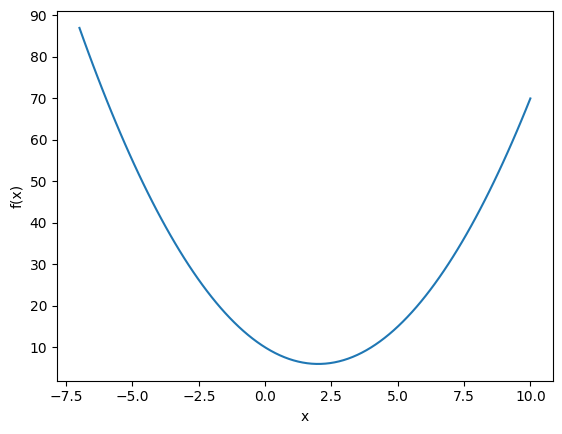

In [3]:
x = np.linspace(-7, 10, 100)
plt.plot(x, f_x1(x))
plt.xlabel('x')
plt.ylabel('f(x)')

In [4]:
### define newton's method for optimization
def my_NM(x, f_x, df_x, ddf_x, x0, n_step=5, a=1):
    cur_x = x0
    for i in range(n_step):
        ### plot f(x)
        plt.plot(x, f_x(x, a))
        plt.xlabel('x')
        plt.ylabel('f(x)')
        
        ### plot f(cur_x)
        plt.scatter(cur_x, f_x(cur_x, a), c='red')
        plt.text(cur_x, f_x(cur_x, a), s=str(np.round(f_x(cur_x, a), 4)))
        
        ### update cur_x according to Newton's optimization step
        print(['cur_x', 'cur_df', 'cur_ddf'])
        print([np.round(cur_x, 4), np.round(df_x(cur_x, a), 4), np.round(ddf_x(cur_x, a), 4)])
        
        cur_x = cur_x - (df_x(cur_x, a)/(ddf_x(cur_x, a)))        
        
        plt.show()
    return cur_x, f_x(cur_x)

['cur_x', 'cur_df', 'cur_ddf']
[-3, -10, 2]


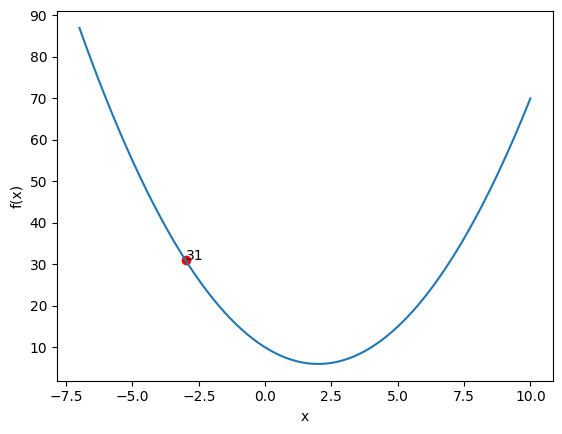

['cur_x', 'cur_df', 'cur_ddf']
[2.0, 0.0, 2]


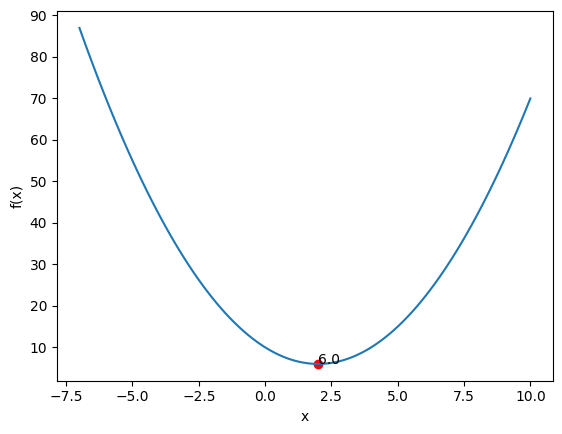

['cur_x', 'cur_df', 'cur_ddf']
[2.0, 0.0, 2]


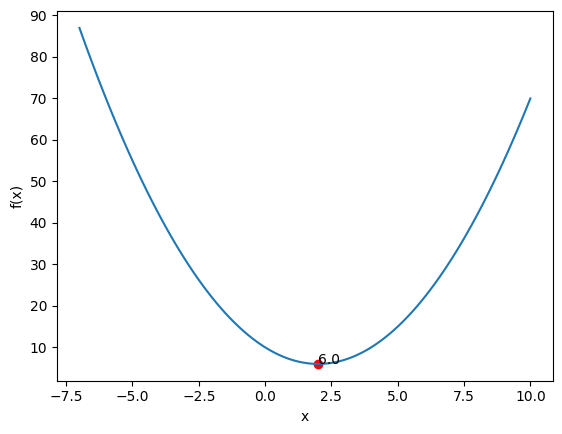

['cur_x', 'cur_df', 'cur_ddf']
[2.0, 0.0, 2]


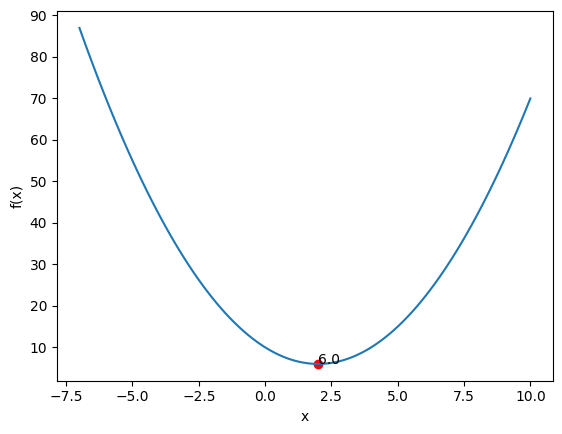

['cur_x', 'cur_df', 'cur_ddf']
[2.0, 0.0, 2]


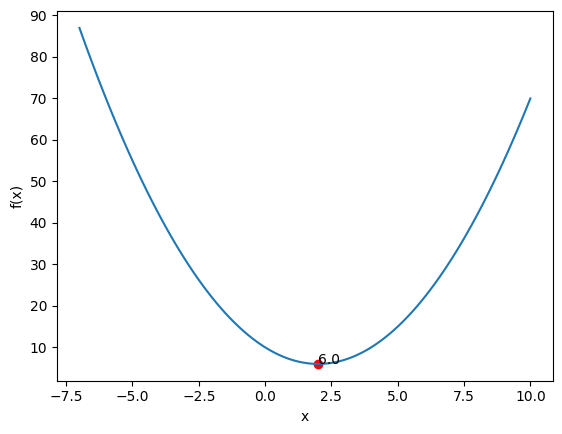

In [5]:
### minimize f1(x)
x = np.linspace(-7, 10, 100)
x_opt, y_opt = my_NM(x, f_x1, df_x1, ddf_x1, x0=-3, a=1)


In [6]:
x_opt

2.0

In [7]:
y_opt

6.0

In [8]:
### define non-convex function
def f_x2(x, a=1):
    return a*(x**5 - 4*x**4 - 2*x**3 + 3*x**2 + x + 10)

def df_x2(x, a=1):
    return a*(5*x**4 - 16*x**3 - 6*x**2 + 6*x + 1)

def ddf_x2(x, a=1):
    return a*(20*x**3 - 48*x**2 - 12*x + 6)

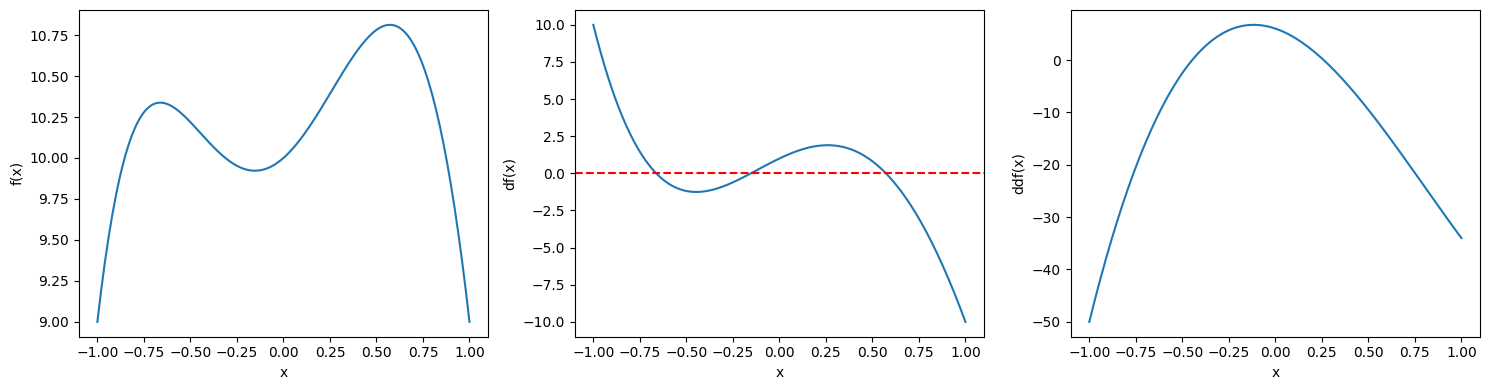

In [18]:
x = np.array(range(-100, 101))/100.0

fig, ax = plt.subplots(1, 3, figsize=(15,4))

ax[0].plot(x, f_x2(x), label='f(x)')
ax[0].set_xlabel('x')
ax[0].set_ylabel('f(x)')

ax[1].plot(x, df_x2(x), label='df(x)')
ax[1].axhline(y=0, color='red', linestyle='dashed')
ax[1].set_xlabel('x')
ax[1].set_ylabel('df(x)')

ax[2].plot(x, ddf_x2(x), label='ddf(x)')
ax[2].set_xlabel('x')
ax[2].set_ylabel('ddf(x)')

plt.tight_layout()

['cur_x', 'cur_df', 'cur_ddf']
[-0.95, 7.6755, -43.0675]


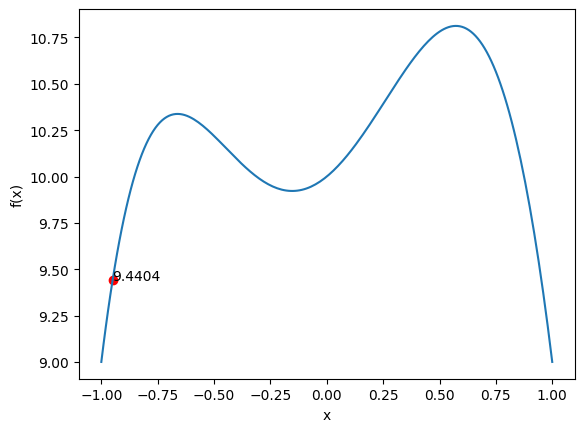

['cur_x', 'cur_df', 'cur_ddf']
[-0.7718, 1.9247, -22.5236]


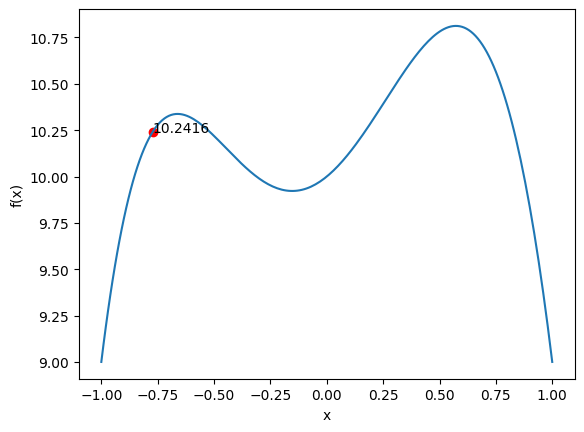

['cur_x', 'cur_df', 'cur_ddf']
[-0.6863, 0.3378, -14.84]


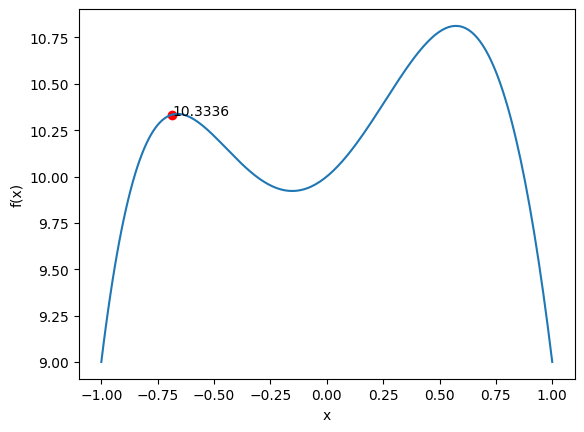

['cur_x', 'cur_df', 'cur_ddf']
[-0.6636, 0.0209, -13.0159]


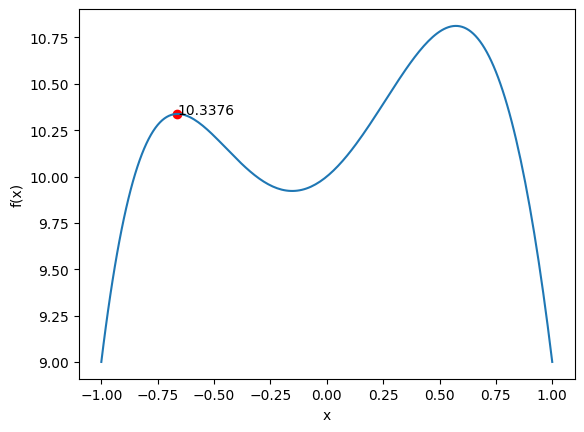

['cur_x', 'cur_df', 'cur_ddf']
[-0.662, 0.0001, -12.8904]


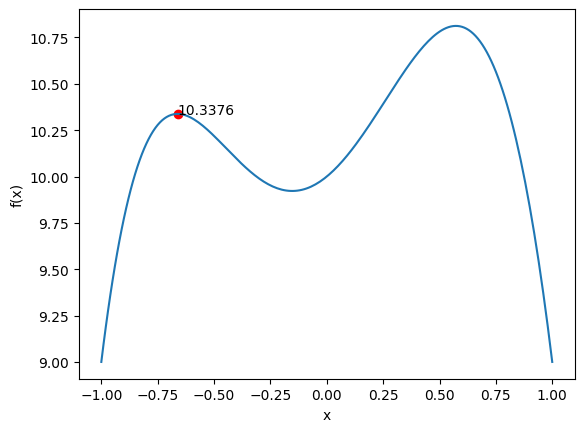

(-0.6619452787019073, 10.33759359521617)

In [10]:
### minimize f2(x)
x = np.array(range(-100, 101))/100.0
my_NM(x, f_x2, df_x2, ddf_x2, x0=-0.95, a=1)

Text([-0.1532381], 9.92211419711776, '9.9221')

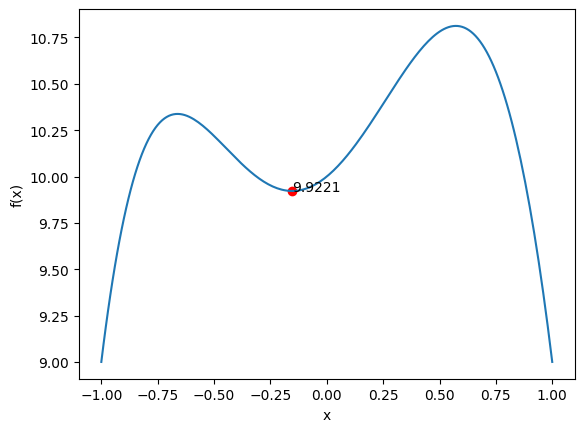

In [13]:
### miminize of f(x)
x = np.array(range(-100, 101))/100.0

fun = lambda x: f_x2(x, a=1)
optim = spo.minimize(fun=fun, x0=np.array(-0.1), method='tnc', bounds=[(-1, 1)])

plt.plot(x, f_x2(x, a=1))
plt.xlabel('x')
plt.ylabel('f(x)')

### plot f(cur_x)
plt.scatter(optim['x'], optim['fun'], c='red')
plt.text(optim['x'], optim['fun'], s=str(np.round(optim['fun'], 4)))

Text([-0.66194528], 10.33759359521617, '10.3376')

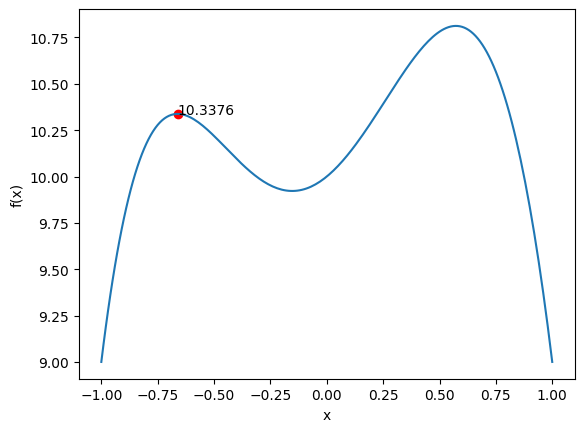

In [14]:
### to maximize f(x), we need miminize of -f(x)
fun = lambda x: f_x2(x, a=-1)
optim = spo.minimize(fun=fun, x0=np.array(-0.2), method='tnc', bounds=[(-1, 1)])

### plot f(x)
plt.plot(x, f_x2(x, a=1))
plt.xlabel('x')
plt.ylabel('f(x)')

### plot f(cur_x)
plt.scatter(optim['x'], -optim['fun'], c='red')
plt.text(optim['x'], -optim['fun'], s=str(np.round(-optim['fun'], 4)))